# **1. Objectif**

L'objectif de ce projet est de concevoir un modèle d'apprentissage automatique capable de segmenter les clients d'une entreprise et de faire ressortir des insights.

# **2. Chargement et exploration des données**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


In [3]:
import pandas as pd
df=pd.read_csv('/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.duplicated().sum()

np.int64(0)

 # **3. EDA (Exploratory Data Analysis)**

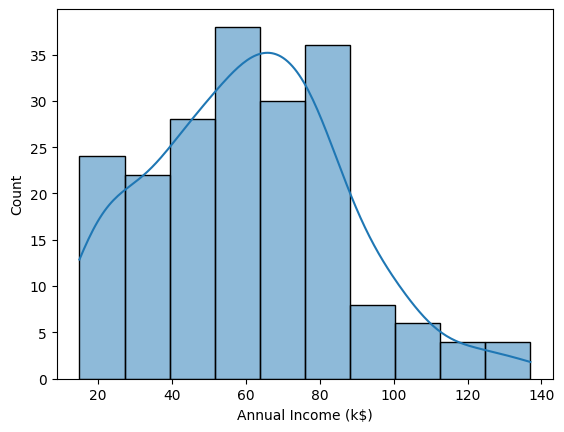

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Annual Income (k$)'], kde=True)
plt.show()

In [11]:
df['Annual Income (k$)'].median()

61.5

L'analyse exploratoire des revenus annuels des clients révèlent quen asymétrie à droite. Cela suggère que la majorité des clients ont des revenus annuels qui ne dépassent pas 80k. Le revenu annuel médian est de 61.5k.

In [15]:
df['Age'].median()

36.0

La majorité des clients à moins de 50 ans. Cela révèle une structure relativement jeune des clients. L'âge médian est de 36 ans.

<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

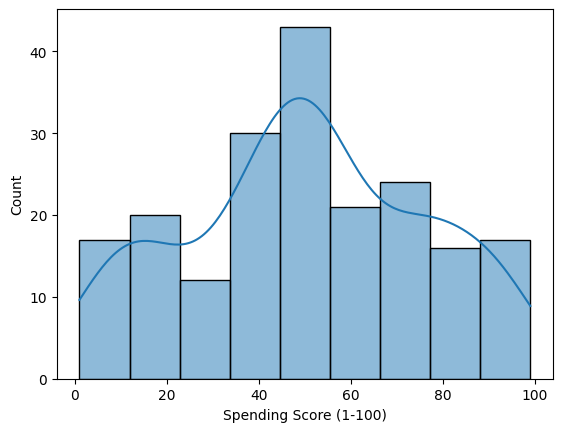

In [22]:
sns.histplot(df['Spending Score (1-100)'], kde=True)

In [23]:
df['Spending Score (1-100)'].median()

50.0

La majorité des clients ont un score de 50. Ceux-ci ont donc des habitudes de consommation plutôt modérée.

In [24]:
import plotly.express as px

In [26]:
fig=px.scatter(data_frame=df, x='Annual Income (k$)', y='Spending Score (1-100)', title='Relation Revenu - Dépense')
fig.show()

L'analyse de la relation Prix - Revenu ne nous permet pas de conclure une corrélation entre ces deux variables. Cependant, nous pouvons apercevoir des groupes:
1. Les clients qui ont un revenu élevé et qui achètent peu
2. Les clients qui ont un revenu bas et qui achètent peu
3. Les clients qui ont un revenu élevé et qui achètent beaucoup
4. Les clients qui ont un revenu bas et qui achètent peu
5. Les clients qui ont revenu modéré et qui achètent de façon modérée.

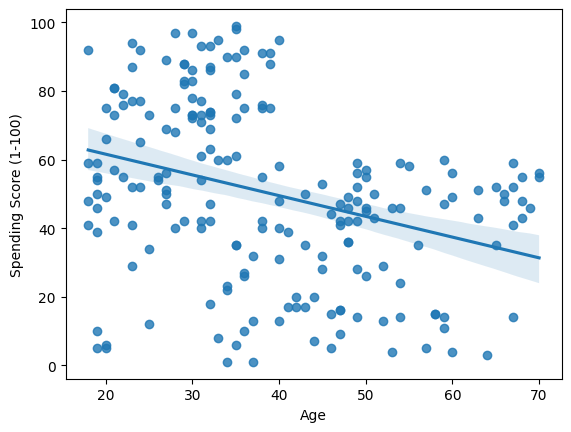

In [33]:
sns.regplot(data=df, x='Age', y='Spending Score (1-100)')
plt.show()

Il existe une assez forte corrélation négative entre l'Age et le score de dépense. Plus le client est agé moins, il achète. Cela peut être le résultat d'une sensibilité du type de client par rapport aux produits.

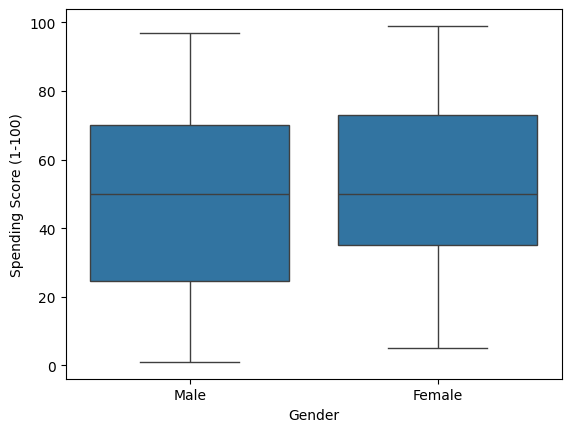

In [36]:
sns.boxplot(x=df['Gender'], y=df['Spending Score (1-100)'])
plt.show()

Les clients hommes et femmes ont quasiment les mêmes score de dépense. De façon exploratoire, le genre n'influence donc pas la consommation des produits.

# **4.MODELISATION**

1. **DBSCAN (Density-Based Spatial Clustering with Application of Noise)**: c'est un algorithme de ML non supervisé basé sur la densité des données. Il regroupe les données en se basant sur les zones denses et détecte les anomalies. Son utilisation ici est pertinente car nous ne connaissons pas le nombre de clusters ou de segments que nous voulons. DBSCAN excelle dans ce domaine.

In [38]:
from sklearn.cluster import DBSCAN

In [45]:
df['Gender']=df['Gender'].apply(lambda x: 0 if x=='Female' else 1)

In [96]:
dbscan=DBSCAN(eps=20, min_samples=20)

In [97]:
X=df.drop(columns=['CustomerID'])

In [162]:
result=dbscan.fit(X_trans)

In [163]:
labels=result.labels_

In [164]:
labels

array([ 0,  0, -1,  0,  0,  0, -1,  0, -1,  0, -1,  0, -1,  0,  0,  0,  0,
        0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, -1,  0, -1, -1, -1, -1, -1, -1])

* **Réduction de dimensionalité**:
L'algorithme de réduction de dimensionalité PCA permet de réduire la dimension des données tout en gardant l'essentiel de l'information. Idéal pour visualiser les données haute dimension en 2D.

In [102]:
from sklearn.decomposition import PCA

In [182]:
pca= PCA(n_components=2, whiten=True)

In [183]:
X_trans=pca.fit_transform(X)

In [184]:
pca.explained_variance_ratio_.sum()

np.float64(0.8920961624646058)

Les nouvelles composantes contiennent environ 90% de la variance.

In [165]:
df['labels']=labels

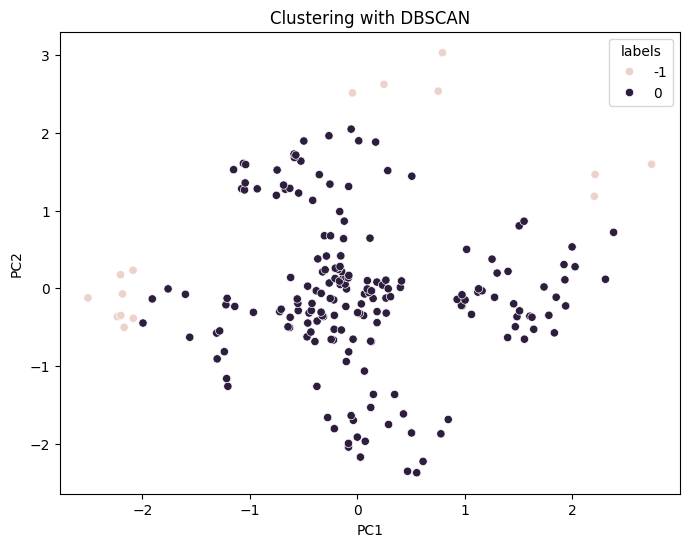

In [185]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=X_trans[:,0], y=X_trans[:,1], hue='labels')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clustering with DBSCAN')
plt.show()

L'utilisation de BDSCAN bien que pertinente dans notre cas, revéle des limites qui nous recommandent de migrer vers des modèles plus intelligents. En effet, cet algorithme est très sensible à son paramètre epsilon. Ce qui le rend plus complexe à utiliser. Une valeur d'epsilon trop instable rendrait ses résultats inutilisables.

2. **HDBSCAN**: est un algorithme de clustering qui s'appuie sur les mêmes principes que DBSCAN mais hiérarchise les groupes.

In [116]:
from sklearn.cluster import HDBSCAN

In [130]:
hdbscan=HDBSCAN(min_cluster_size=3)

In [158]:
result_hdb=hdbscan.fit_predict(X)

In [159]:
result_hdb

array([-1,  4, -1,  4,  5,  4, -1, -1, -1,  4, -1, -1,  6,  4, -1,  4,  5,
       -1, -1, -1,  5,  4, -1,  4,  6,  4,  5, -1,  5,  4, -1,  4,  6,  4,
        6,  4,  6,  4,  6,  4, -1,  4, -1,  8, -1, -1, -1,  8,  8,  8, 15,
        8,  8, -1, 15, 15, 15, 12,  8, 15, 12, 11, 12, 12, 12, 11, 14, 12,
       11,  8, 12, 16, 12, 12, 12, 10, 14, 14, 10, 16, 12, -1, -1, 16, 10,
       16, -1, 10, -1, 16,  7, 10, 16,  9,  9, 10, 16, 10, 16, 10, 10, 16,
        7, 10, 13, 10,  7, 16,  7,  7,  7, 10,  9, 10, 10, 10,  7, 13, -1,
       13, -1,  9, -1,  0, -1,  0,  9,  0, -1,  0,  2,  0, -1,  0,  1,  0,
        2,  0,  1,  0,  2,  0, -1,  0,  1,  0, -1,  0,  2,  0,  2,  0,  2,
        0,  2,  0,  2,  0, -1,  0, -1,  0,  1,  0,  2,  0,  2,  0,  2,  0,
        2,  0, -1,  0,  3,  0,  3,  0,  3,  0,  2,  0, -1,  0, -1,  0, -1,
        0,  2,  0,  2, -1, -1,  0, -1,  0, -1,  0, -1, -1])

In [160]:
df['result_hdb']=result_hdb

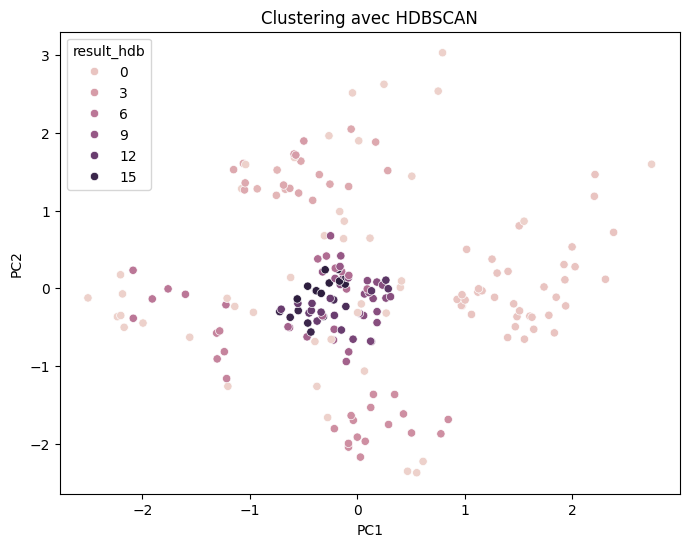

In [186]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=X_trans[:,0], y=X_trans[:,1], hue='result_hdb')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clustering avec HDBSCAN')
plt.show()

3. **HAC**: C'est un algorithme qui crée des clusters de façon agglomérative. Les points les plus proches s'assemblent jusqu'à obtenir un seul grand cluster.

In [138]:
from sklearn.cluster import AgglomerativeClustering

In [139]:
Agc= AgglomerativeClustering(n_clusters=3)

In [151]:
labels_agc=Agc.fit_predict(X)

In [152]:
df['labels_agc']=labels_agc

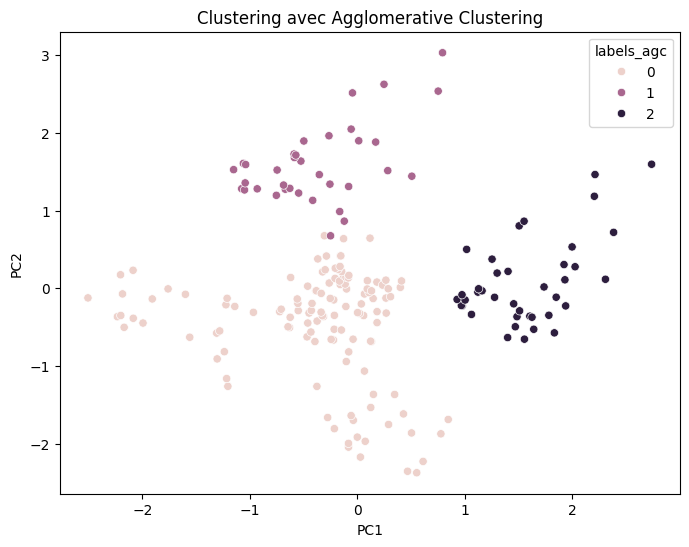

In [187]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=X_trans[:,0], y=X_trans[:,1], hue='labels_agc')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clustering avec Agglomerative Clustering')
plt.show()

4. **KMEAN**: centré sur les centroids. Idéal quand on connait le nombre de clusters à trouver.

In [168]:
from sklearn.cluster import KMeans

In [196]:
inertia=[]
for n in list(range(1,10)):
  kmean=KMeans(n_clusters=n)
  kmean.fit(X_trans)
  inertia.append(kmean.inertia_)
inertia_df=pd.DataFrame({range(1,10):inertia})

<Figure size 800x600 with 0 Axes>

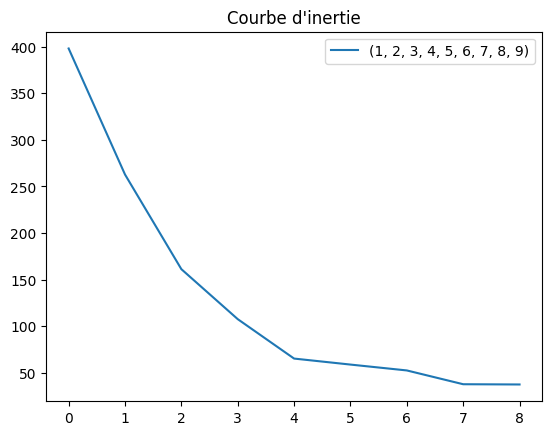

In [199]:
plt.figure(figsize=(8,6))
inertia_df.plot(kind='line')
plt.title("Courbe d'inertie")
plt.show()

La courbe d'inertie nous montre que le nombre de clusters optimal est 3.

In [200]:
kmean=KMeans(n_clusters=3)

In [205]:
kmean.fit(X)
df['labels_kmean']=kmean.predict(X)

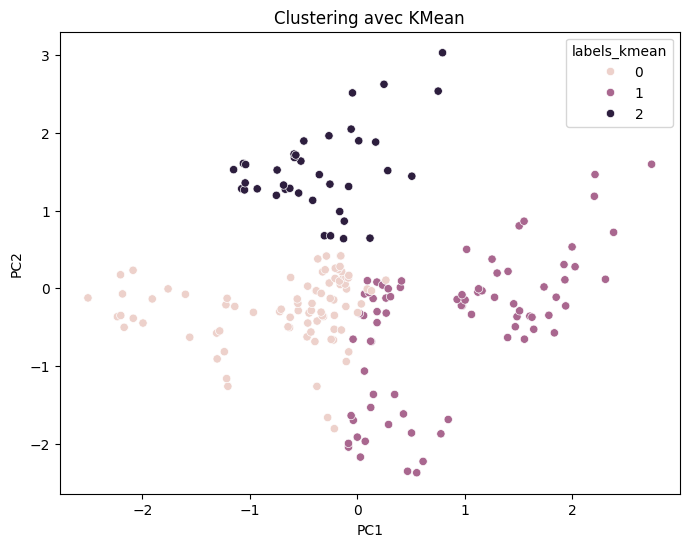

In [207]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=X_trans[:,0], y=X_trans[:,1], hue='labels_kmean')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clustering avec KMean')
plt.show()

Après test de plusieurs modèles, le modèle KMEAN sera sélectionné pour sa facilité d'utilisation, son interpretabilité et sa capacité à avoir des résultats mesurables.

In [211]:
cluster_1= df[df['labels_kmean']==0]
cluster_2= df[df['labels_kmean']==1]
cluster_3= df[df['labels_kmean']==2]

# **5. Recommandations business**

### Intégration de l'API Google Gemini pour l'Interprétation des Clusters et recommandations buiness

Nous allons maintenant utiliser l'API Gemini pour interpréter les caractéristiques de chaque cluster et générer des recommandations business actionnables.

In [218]:
# Import the Python SDK
import google.generativeai as genai
# Used to securely store your API key
from google.colab import userdata

# Configure the API key
# Make sure you have your API key stored as 'GOOGLE_API_KEY' in Colab's secrets manager
GEMINI_API_KEY=userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)

# Initialize the Gemini model
gemini_model = genai.GenerativeModel('gemini-2.5-flash')

print("Google Gemini API configured and model initialized.")

Google Gemini API configured and model initialized.


In [219]:
# Préparer le prompt pour le LLM avec les statistiques des clusters
prompt = f"""J'ai effectué une segmentation client en 3 clusters en utilisant l'algorithme K-Means. Voici les clusters:

**Cluster 1 (labels_kmean=0):**
{cluster_1}

**Cluster 2 (labels_kmean=1):**
{cluster_2}

**Cluster 3 (labels_kmean=2):**
{cluster_3}


Interprète chacun de ces trois clusters de manière précise et concise, en identifiant les caractéristiques clés qui les définissent. Ensuite, pour chaque cluster, propose des recommandations business pertinentes et actionnables. Les recommandations doivent être spécifiques et orientées vers la maximisation de la valeur client ou l'amélioration de l'engagement, en tenant compte des caractéristiques de chaque segment.

Assure-toi que les recommandations sont concises et directement applicables. """

print("Prompt préparé pour le LLM.")

# Générer la réponse de l'LLM
response = gemini_model.generate_content(prompt)

# Afficher l'interprétation et les recommandations
print("\n--- Interprétation et Recommandations Business par Gemini ---\n")
print(response.text)

Prompt préparé pour le LLM.

--- Interprétation et Recommandations Business par Gemini ---

Voici l'interprétation de chaque cluster K-Means, suivie de recommandations business pertinentes et actionnables.

Pour faciliter l'interprétation, nous allons nous concentrer sur les variables clés : **Age, Annual Income (k$) et Spending Score (1-100)**.

---

### Interprétation des Clusters et Recommandations Business

#### Cluster 1 (labels_kmean=0) : Les "Économes à Revenus Modestes"

*   **Caractéristiques Clés :**
    *   **Revenu Annuel (Annual Income k$):** Généralement faible à modéré (ex: 15k à 67k).
    *   **Score de Dépenses (Spending Score 1-100):** Faible à modéré (ex: 3 à 57).
    *   **Âge:** Varié, allant des jeunes adultes aux seniors.
    *   **Description :** Ce segment regroupe des clients avec des revenus modestes et un faible pouvoir d'achat. Ils sont très sensibles aux prix et dépensent de manière très réfléchie, voire parcimonieuse. Ils recherchent le bon rapport qualit

 Prompt préparé pour le LLM.

--- Interprétation et Recommandations Business par Gemini ---

Voici l'interprétation de chaque cluster K-Means, suivie de recommandations business pertinentes et actionnables.

Pour faciliter l'interprétation, nous allons nous concentrer sur les variables clés : **Age, Annual Income (k$) et Spending Score (1-100)**.

---

### Interprétation des Clusters et Recommandations Business

#### Cluster 1 (labels_kmean=0) : Les "Économes à Revenus Modestes"

*   **Caractéristiques Clés :**
    *   **Revenu Annuel (Annual Income k$):** Généralement faible à modéré (ex: 15k à 67k).
    *   **Score de Dépenses (Spending Score 1-100):** Faible à modéré (ex: 3 à 57).
    *   **Âge:** Varié, allant des jeunes adultes aux seniors.
    *   **Description :** Ce segment regroupe des clients avec des revenus modestes et un faible pouvoir d'achat. Ils sont très sensibles aux prix et dépensent de manière très réfléchie, voire parcimonieuse. Ils recherchent le bon rapport qualité-prix et les bonnes affaires.

*   **Recommandations Business :**
    1.  **Offres à Valeur Ajoutée & Promotions :** Mettre en place des promotions régulières, des offres "achetez-en un, obtenez-en un gratuit" ou des packs économiques.
    2.  **Programme de Fidélité Axé sur les Économies :** Créer un programme de fidélité qui récompense les achats avec des remises directes ou des points échangeables contre des produits à prix réduits.
    3.  **Communication sur le Prix :** Mettre en avant les prix bas, les promotions et les économies potentielles dans toutes les communications marketing.
    4.  **Produits Essentiels et Accessibles :** Prioriser la promotion de produits de base et d'articles essentiels à des prix compétitifs.

#### Cluster 2 (labels_kmean=1) : Les "Dépensiers Impulsifs / Passionnés"

*   **Caractéristiques Clés :**
    *   **Revenu Annuel (Annual Income k$):** Très varié, allant de faible à très élevé (ex: 15k à 137k).
    *   **Score de Dépenses (Spending Score 1-100):** Très élevé (ex: 69 à 99).
    *   **Âge:** Généralement plus jeunes à adultes (ex: 21 à 38).
    *   **Description :** Ce segment se distingue par un score de dépenses extrêmement élevé, quelle que soit leur capacité de revenu. Ils sont très engagés, aiment acheter et sont probablement sensibles aux tendances. Leur loyauté pourrait être élevée s'ils trouvent ce qu'ils cherchent.

*   **Recommandations Business :**
    1.  **Programme de Fidélité VIP / Expérience Premium :** Offrir un programme de fidélité exclusif avec des avantages premium (accès anticipé aux ventes, service client dédié, événements spéciaux, cadeaux personnalisés).
    2.  **Recommandations Personnalisées & Nouveautés :** Utiliser des systèmes de recommandation sophistiqués et les informer en priorité des nouveautés et des produits haut de gamme ou en édition limitée.
    3.  **Upselling et Cross-selling :** Proposer activement des produits complémentaires ou des versions améliorées de leurs achats précédents.
    4.  **Contenu Engageant & Tendance :** Créer du contenu (blogs, réseaux sociaux, lookbooks) qui inspire et met en scène les produits de manière attrayante et tendance.

#### Cluster 3 (labels_kmean=2) : Les "Forts Revenus, Faibles Dépenses"

*   **Caractéristiques Clés :**
    *   **Revenu Annuel (Annual Income k$):** Élevé à très élevé (ex: 70k à 137k).
    *   **Score de Dépenses (Spending Score 1-100):** Très faible (ex: 1 à 40).
    *   **Âge:** Varié, allant des jeunes adultes aux seniors.
    *   **Description :** Ce segment possède un pouvoir d'achat élevé, mais leurs dépenses sont étonnamment faibles. Il s'agit d'une opportunité majeure. Ils pourraient être très sélectifs, exigeants, ou simplement ne pas trouver une offre qui les interpelle suffisamment pour dépenser davantage.

*   **Recommandations Business :**
    1.  **Identifier les Freins à l'Achat :** Mener des enquêtes qualitatives ou analyser le parcours client pour comprendre pourquoi ils ne dépensent pas plus (manque de produits pertinents, expérience d'achat insatisfaisante, etc.).
    2.  **Offres Ultra-Personnalisées et Exclusives :** Proposer des produits de luxe, des services sur mesure (e.g., styliste personnel, configurateur de produits) ou des collections exclusives qui correspondent à leurs préférences potentielles.
    3.  **Miser sur la Qualité et la Valeur Durable :** Ne pas se focaliser sur le prix, mais plutôt sur la qualité supérieure, la durabilité, l'artisanat et l'exclusivité des produits.
    4.  **Événements et Expériences Exclusives :** Inviter à des événements privés, des ateliers ou des préventes pour leur donner un sentiment d'appartenance et de privilège.
    5.  **Partenariats Stratégiques :** Collaborer avec des marques ou des services de luxe qui complètent votre offre et peuvent attirer ce segment.
